<div style = "text-align:center; padding:30px 0;" >
  <h1 style = "margin-bottom:0">Modelo de Machine Learning para Fuga de clientes de Interconnect</h1>
  <p style = "margin-top:6px; font-size:18px; color:#666;">
    Autor: Alan • Fecha: Abril 26, 2026</p>
</div>

# Objetivo
operador de telecomm Interconnect quiere pronosticar su tasa de cancelacion de clientes
Si se quiere ir el cliente, el equipo de ventas hará una estrategia para mantener al cliente

* Servicios de Interconnect:
    Interconnect proporciona principalmente dos tipos de servicios:

    1. Comunicación por teléfono fijo. El teléfono se puede conectar a varias líneas de manera simultánea.
    2. Internet. La red se puede configurar a través de una línea telefónica (DSL, *línea de abonado digital*) o a través de un cable de fibra óptica.

* Algunos otros servicios que ofrece la empresa incluyen:

    - Seguridad en Internet: software antivirus (*ProtecciónDeDispositivo*) y un bloqueador de sitios web maliciosos (*SeguridadEnLínea*).
    - Una línea de soporte técnico (*SoporteTécnico*).
    - Almacenamiento de archivos en la nube y backup de datos (*BackupOnline*).
    - Streaming de TV (*StreamingTV*) y directorio de películas (*StreamingPelículas*)

La clientela puede elegir entre un pago mensual o firmar un contrato de 1 o 2 años. Puede utilizar varios métodos de pago y recibir una factura electrónica después de una transacción.

In [164]:
# IMportar librerias
import numpy as np
import pandas as pd

import math
from scipy import stats
from scipy.stats import norm, skew

import matplotlib.pyplot as plt
import matplotlib
palette = plt.get_cmap('Set2')

import seaborn as sns

import missingno as msno

from datetime import datetime, timedelta
import os

import warnings

from sklearn.preprocessing import LabelEncoder


# ANALISIS EXPLORATORIO DE DATOS (EDA)

In [165]:
# Primer dataset: personal.csv
df_personal = pd.read_csv('C:\\Users\\alan_\\Documents\\Telecom project\\personal.csv')
# Primeras 5 columnas
print(df_personal.info())
df_personal.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB
None


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


c:\Users\alan_\anaconda3\envs\tf_gpu\lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


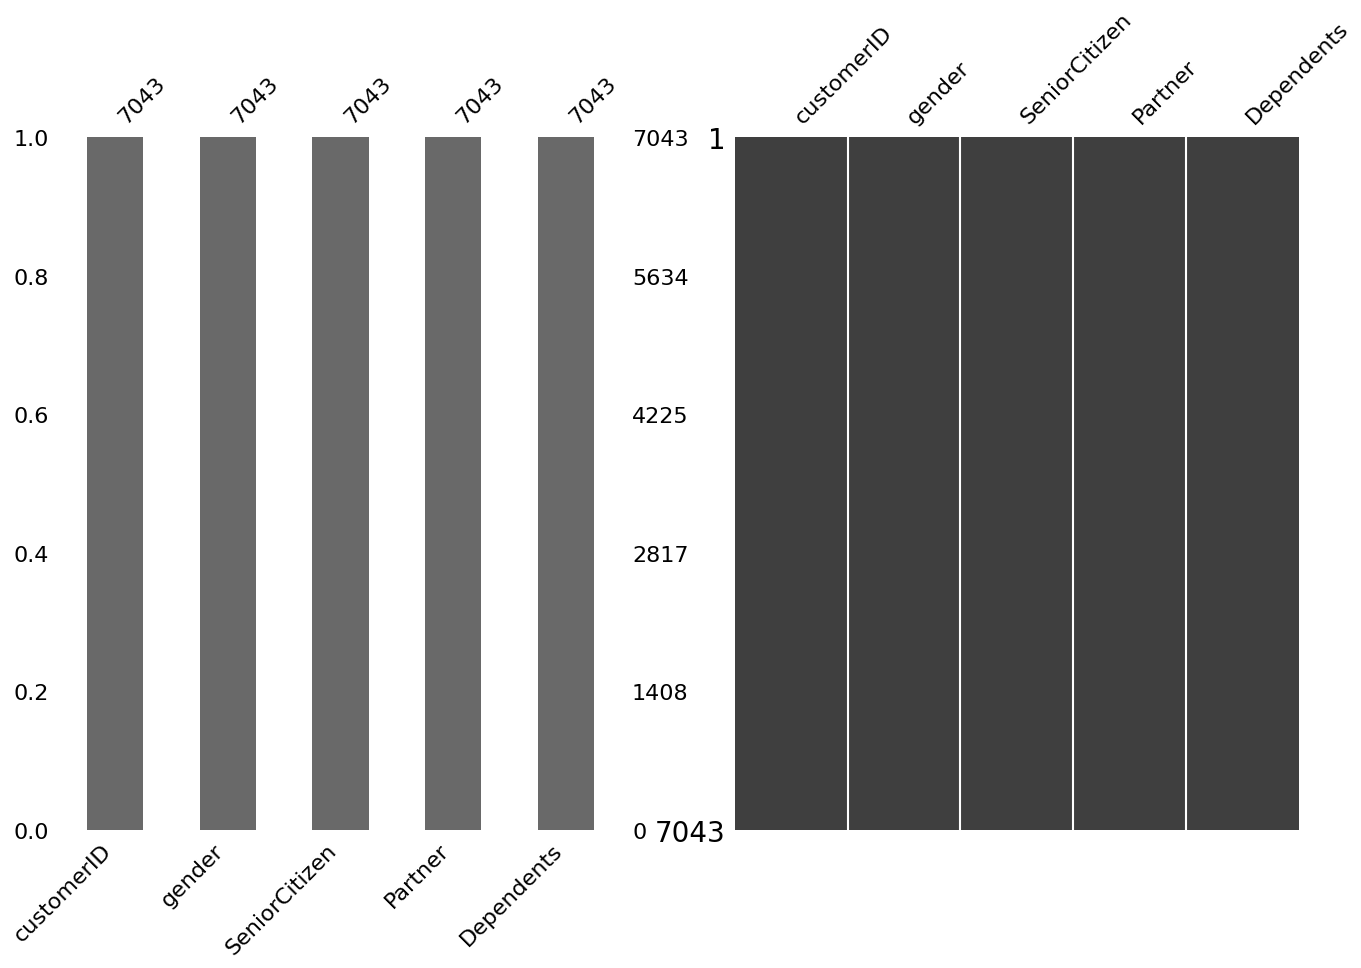

In [166]:
# Explorarando datos faltantes

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
msno.bar(df_personal, figsize=(10, 7), ax=axes[0])
msno.matrix(df_personal, figsize=(10, 7), ax=axes[1])
plt.show()

Acorde al tipo de datos y la naturaliza de los mismos, no es necesario hacer un analisis mas profundo por el momento. Todo parece indicar que está bien, no hay datos nulos en el data frame.

In [167]:
# Segundo dataset: internet.csv
df_internet = pd.read_csv('C:\\Users\\alan_\\Documents\\Telecom project\\internet.csv')
# Primeras 5 columnas
print(df_internet.info())
df_internet.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB
None


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


c:\Users\alan_\anaconda3\envs\tf_gpu\lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


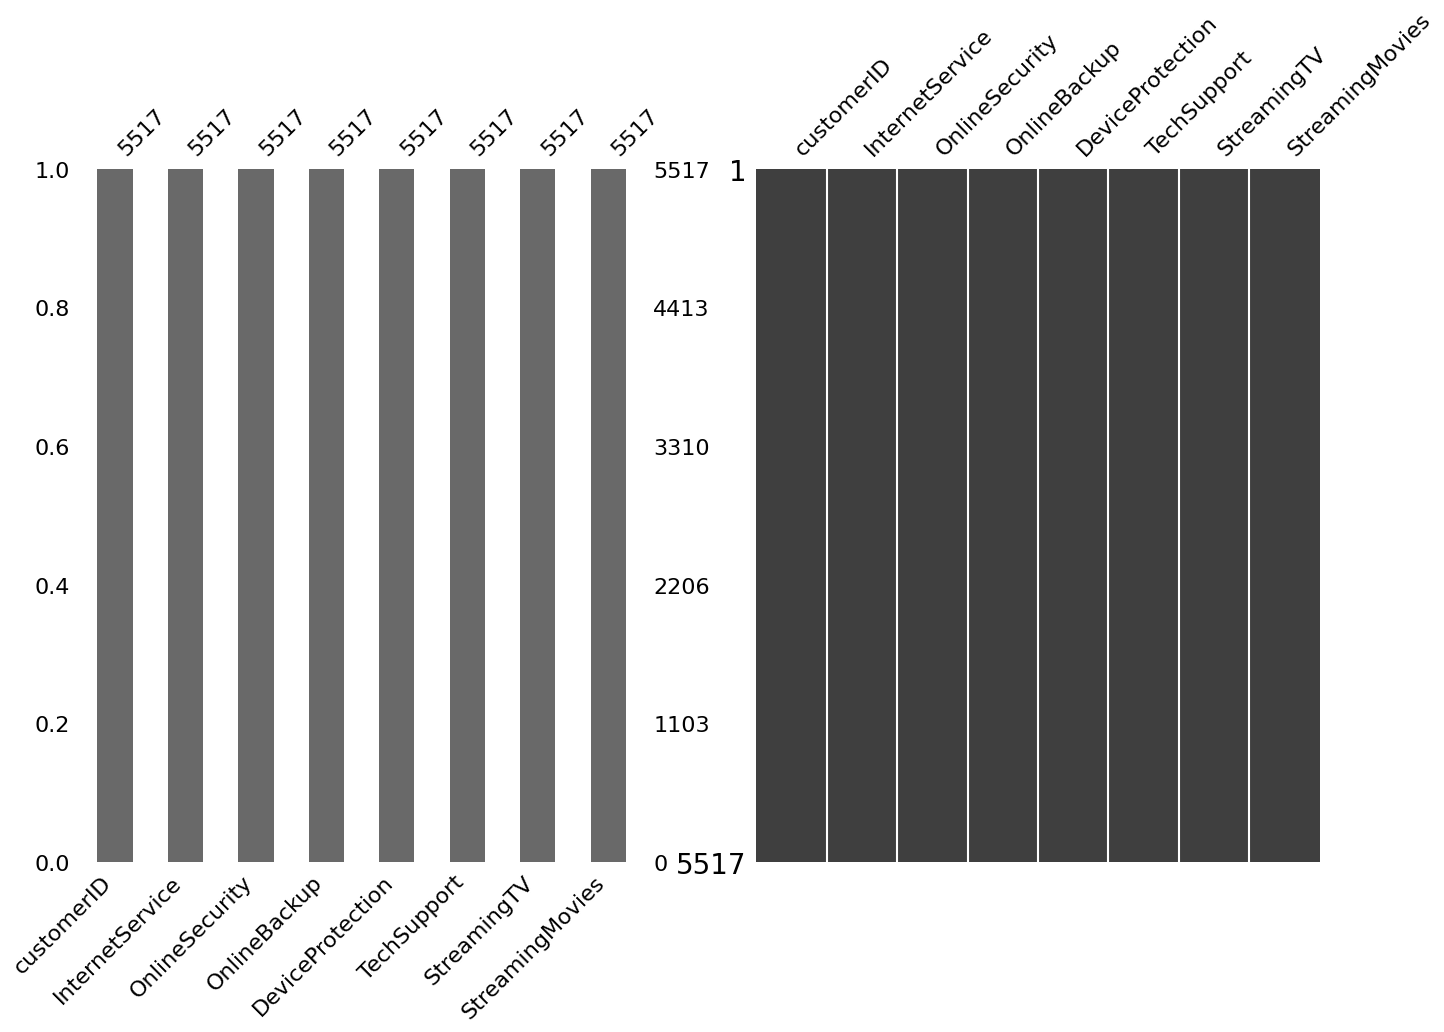

In [168]:
# Explorarando datos faltantes

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
msno.bar(df_internet, figsize=(10, 7), ax=axes[0])
msno.matrix(df_internet, figsize=(10, 7), ax=axes[1])
plt.show()

De igual manera, los datos se ven bien, no hay datos faltantes. Aunque el tamaño de columnas es menor al primer dataframe

In [169]:
# Tercer dataset: contract.csv
df_contract = pd.read_csv('C:\\Users\\alan_\\Documents\\Telecom project\\contract.csv')
# Primeras 5 columnas
print(df_contract.info())
df_contract.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
None


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


c:\Users\alan_\anaconda3\envs\tf_gpu\lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


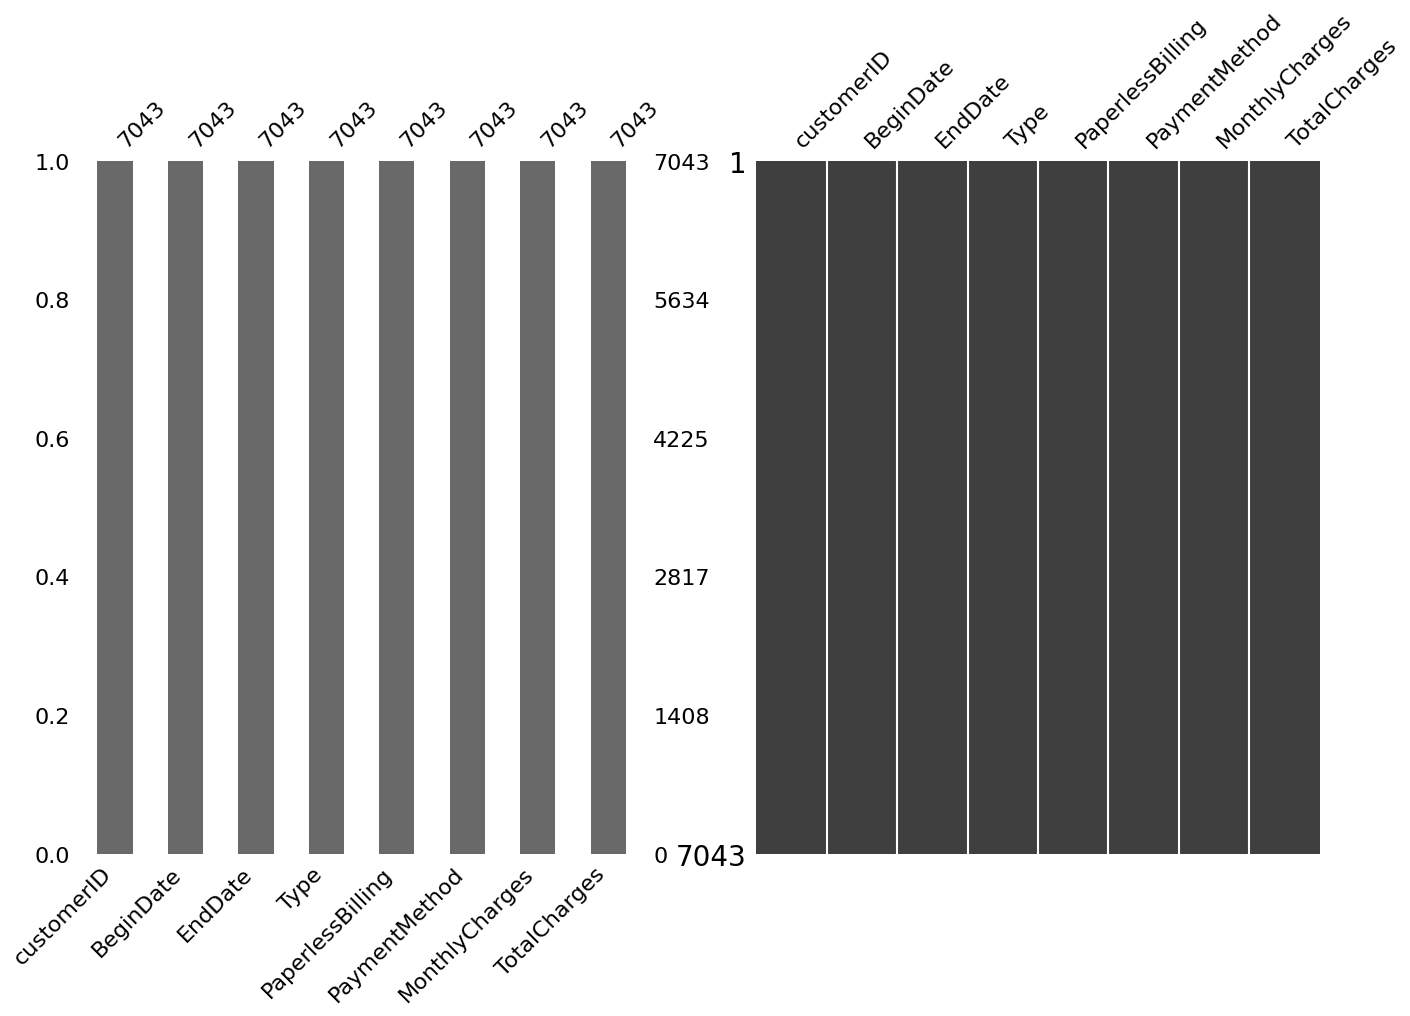

In [170]:
# Exlporarando datos faltantes
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
msno.bar(df_contract, figsize=(10, 7), ax=axes[0])
msno.matrix(df_contract, figsize=(10, 7), ax=axes[1])
plt.show()

En este dataset NO hay datos faltantes, y se obseva que el tamaño de este es igual al primero.

In [171]:
# Cuarto dataset: phone.csv
df_phone = pd.read_csv('C:\\Users\\alan_\\Documents\\Telecom project\\phone.csv')
# Primeras 5 columnas
print(df_phone.info())
df_phone.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB
None


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


c:\Users\alan_\anaconda3\envs\tf_gpu\lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


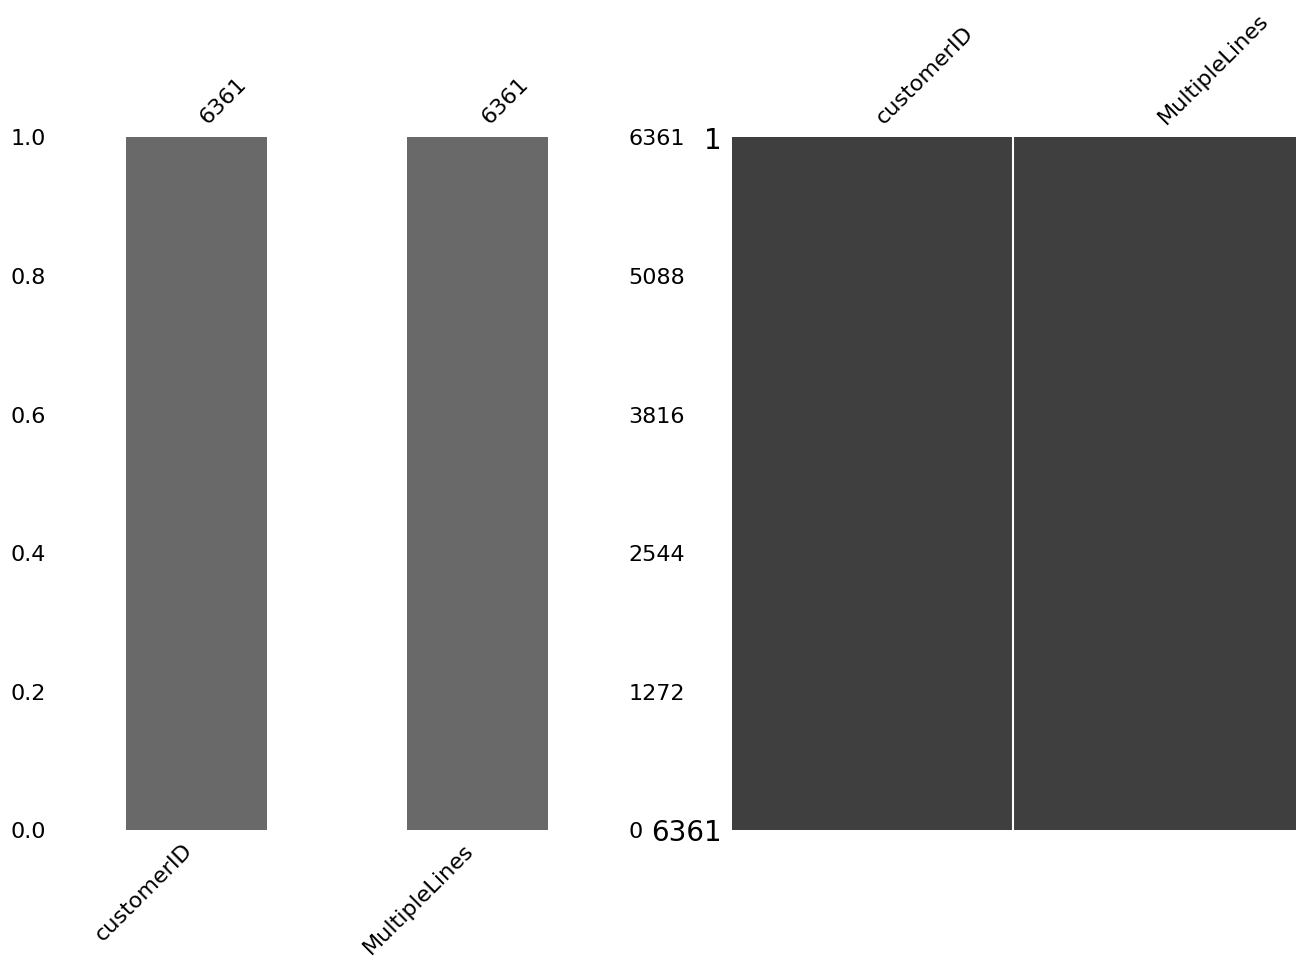

In [172]:
# Explorando datos faltantes
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
msno.bar(df_phone, figsize=(10, 7), ax=axes[0])
msno.matrix(df_phone, figsize=(10, 7), ax=axes[1])
plt.show()

Al igual que en los otros dataframes, este no cuenta con datos faltantes, sin embargo la cantidad de datos es menor al primer dataframe, pero mayor al segundo.

Vamos a anlizar las columnas existentes en los 4 dataframes: 

- `customerID`: Es el ID del cliente en la fila
- `gender`: Es el genero del cliente (Female, Male) [Object]
- `SeniorCitizen`: Indica si el cliente es mayor o no (0, 1) [int]
- `Partner`: Indica si el cliente tiene pareja o no (NO, YES) [object]
- `Dependents`: Indica si el cliente tiene dependencias economicas (NO, YES) [object]
- `InternetService`: Indica que tipo de servicio de internet tiene el cliente (Fiber optic, DSL) [object]
- `OnlineSecurity`: Indica si el cliente cuenta con Seguridad Online (NO, YES) [object]
- `OnlineBackup`: Indica si el cliente cuenta con Respaldo ONline (NO, YES) [object]
- `DeviceProtection`: Indica si el cliente cuenta con proteccion para su equipo (NO, YES) [object]
- `Tech support`: Indica si el cliente cuenta con soporte tecnico (NO, YES) [object]
- `StreamingTV`: Indica si el cliente cuenta con servicio de StreamingTV (NO, YES) [object]
- `StreamingMovies`: Indica si el cliente cuenta con servicio de StreamingMOvies (NO, YES) [object]
- `BeginDate`: Indica la fecha en la que el cliente comenzo su contraro (variado) [object, necesario tener que cambiar a DateTime]
- `EndDate`: Indica la fecha en la que el cliente terminó su contrato ES LA COLUMNA IMPORTANTE A PREDECIR (NO, variado) [object, necesario tener que cambiar a DateTime]
- `Type`: Indica el tipo de servicio que tiene el cliente (Month-to-month, Two year, One year) [object]
- `PaperlessBilling`: Indica si el tramite fue sin llenar formatos (NO, YES) [object]
- `PaymentMethod`: Indica el tipo de pago que hace el cliente (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)) [object]
- `MonthyChargers`: Indica el precio mensual que tiene el cliente (variado) [float64]
- `TotalChargers`: Indica el monto tal de cargos (variado) [object, necesario cambiarlo al tipo correcto flotante]
- `MultipleLines`: Indica si el cliente usa multiples lineas (NO, YES) [object]

Hagamos un tratamiento de datos para poder hacer un analisis real de columnas importantes y su impacto en el objetivo real.

In [173]:
# Fusionar datasets en 'customerID'
df_merged = df_personal.merge(df_internet, on='customerID', how='outer') \
    .merge(df_contract, on='customerID', how='outer') \
    .merge(df_phone, on='customerID', how='outer')
print(df_merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   InternetService   5517 non-null   object 
 6   OnlineSecurity    5517 non-null   object 
 7   OnlineBackup      5517 non-null   object 
 8   DeviceProtection  5517 non-null   object 
 9   TechSupport       5517 non-null   object 
 10  StreamingTV       5517 non-null   object 
 11  StreamingMovies   5517 non-null   object 
 12  BeginDate         7043 non-null   object 
 13  EndDate           7043 non-null   object 
 14  Type              7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [174]:
# Dataframe final y Primeras 5 columnas
print(df_merged.info())
df_merged.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   InternetService   5517 non-null   object 
 6   OnlineSecurity    5517 non-null   object 
 7   OnlineBackup      5517 non-null   object 
 8   DeviceProtection  5517 non-null   object 
 9   TechSupport       5517 non-null   object 
 10  StreamingTV       5517 non-null   object 
 11  StreamingMovies   5517 non-null   object 
 12  BeginDate         7043 non-null   object 
 13  EndDate           7043 non-null   object 
 14  Type              7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines
0,0002-ORFBO,Female,0,Yes,Yes,DSL,No,Yes,No,Yes,Yes,No,2019-05-01,No,One year,Yes,Mailed check,65.6,593.3,No
1,0003-MKNFE,Male,0,No,No,DSL,No,No,No,No,No,Yes,2019-05-01,No,Month-to-month,No,Mailed check,59.9,542.4,Yes
2,0004-TLHLJ,Male,0,No,No,Fiber optic,No,No,Yes,No,No,No,2019-09-01,2020-01-01 00:00:00,Month-to-month,Yes,Electronic check,73.9,280.85,No
3,0011-IGKFF,Male,1,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,2018-12-01,2020-01-01 00:00:00,Month-to-month,Yes,Electronic check,98.0,1237.85,No
4,0013-EXCHZ,Female,1,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,2019-09-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,83.9,267.4,No


c:\Users\alan_\anaconda3\envs\tf_gpu\lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


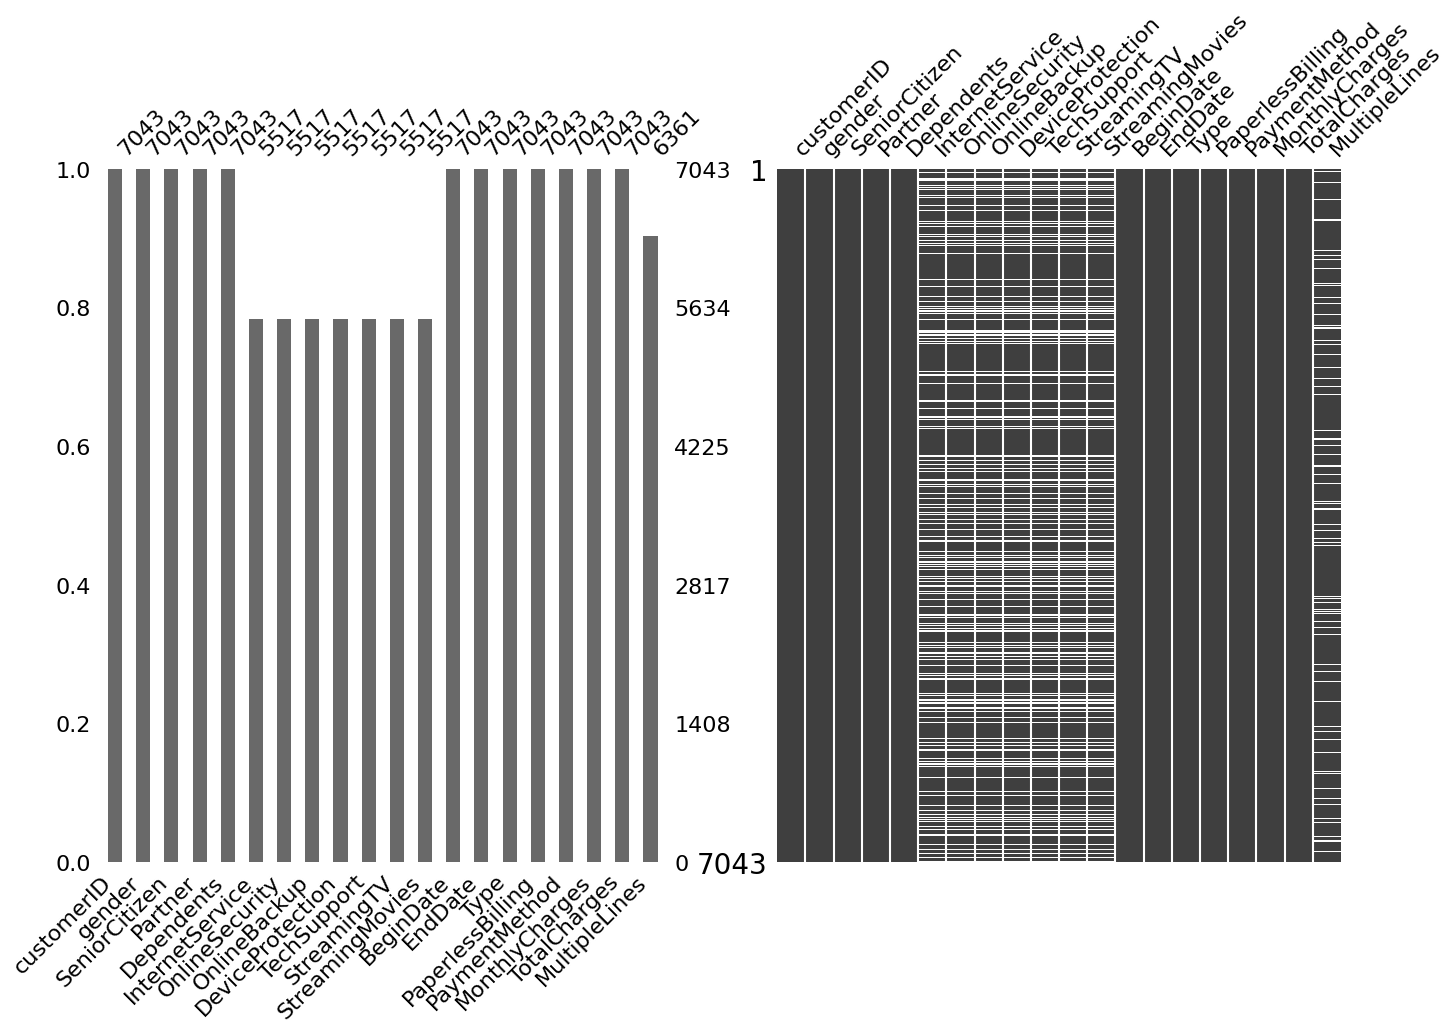

In [175]:
# Explorando datos faltantes
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
msno.bar(df_merged, figsize=(10, 7), ax=axes[0])
msno.matrix(df_merged, figsize=(10, 7), ax=axes[1])
plt.show()

Se realizó una fusion de los 4 dataframes, usando de referencia la columna `customerID`. El resultado marca que hay variables ausentes, esto por el tamaño de los dataframes. Hay que hacer un tratamiento de estos valores usentes

In [176]:
# Tratamiento de datos faltantes
n = df_merged['InternetService'].isnull().sum()
print(f'Número de datos faltantes en InternetService: {n}')
print('Numero total de filas: ', df_merged.shape[0])
print(f'Porcentaje de datos faltantes en el dataset: {n/df_merged.shape[0]*100:.2f}%')

Número de datos faltantes en InternetService: 1526
Numero total de filas:  7043
Porcentaje de datos faltantes en el dataset: 21.67%


In [177]:
print(df_merged.isnull().sum())
df_merged.head(5)

customerID             0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
MultipleLines        682
dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines
0,0002-ORFBO,Female,0,Yes,Yes,DSL,No,Yes,No,Yes,Yes,No,2019-05-01,No,One year,Yes,Mailed check,65.6,593.3,No
1,0003-MKNFE,Male,0,No,No,DSL,No,No,No,No,No,Yes,2019-05-01,No,Month-to-month,No,Mailed check,59.9,542.4,Yes
2,0004-TLHLJ,Male,0,No,No,Fiber optic,No,No,Yes,No,No,No,2019-09-01,2020-01-01 00:00:00,Month-to-month,Yes,Electronic check,73.9,280.85,No
3,0011-IGKFF,Male,1,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,2018-12-01,2020-01-01 00:00:00,Month-to-month,Yes,Electronic check,98.0,1237.85,No
4,0013-EXCHZ,Female,1,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,2019-09-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,83.9,267.4,No


Debido a la naturaleza de los datos donde hacen falta valores, su mayoria son datos binarios, por lo que hace compleja algun tipo de llenado logico y racional para tener datos certeros. La falta de datos consta de un 21.67%, si se elimina habria una cantidad final de 4835 datos completos y no nulos, cantidad suficiente para poder analizar, entrenar y vaidar un modelo de Machine Learning con un resultado confiable.

In [178]:
# Eliminar filas con datos faltantes en el dataset
df_merged_clean = df_merged.dropna()
print(f'Número de filas después de eliminar datos faltantes: {df_merged_clean.shape[0]}')

Número de filas después de eliminar datos faltantes: 4835


c:\Users\alan_\anaconda3\envs\tf_gpu\lib\site-packages\missingno\missingno.py:61: UserWarning: Plotting a sparkline on an existing axis is not currently supported. To remove this warning, set sparkline=False.
  warnings.warn(


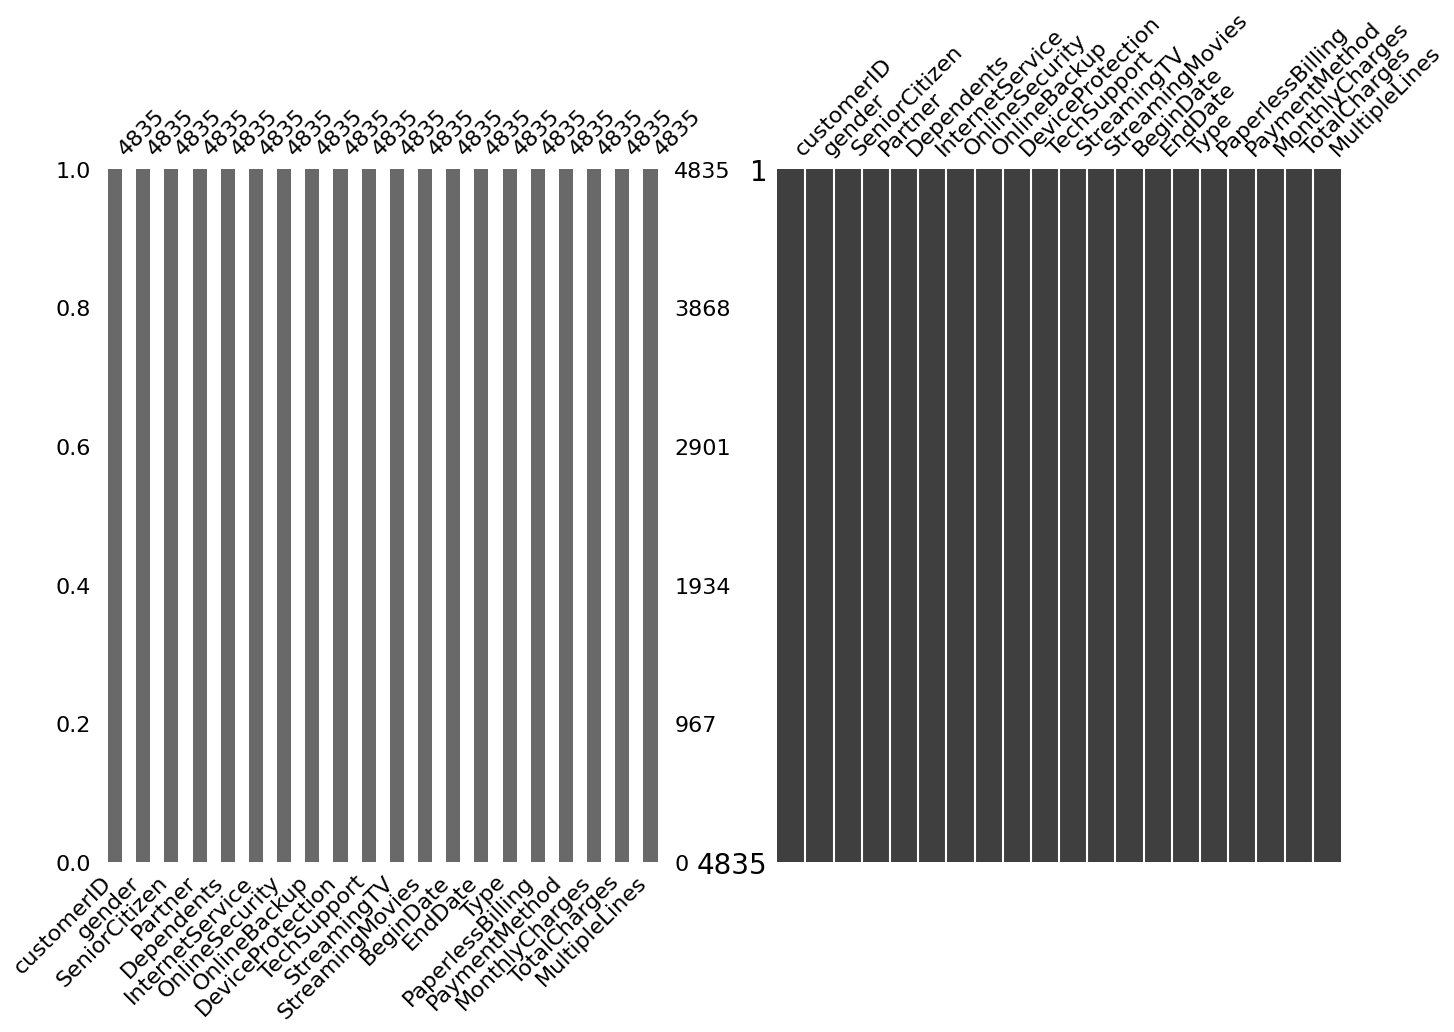

In [179]:
# Explorando datos faltantes
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
msno.bar(df_merged_clean, figsize=(10, 7), ax=axes[0])
msno.matrix(df_merged_clean, figsize=(10, 7), ax=axes[1])
plt.show()

Para el tratamiento de los datos se harán los cambios de datos para BeginDate, EndDate y para TotalChargers. Y para facilitar la lectura, se moverá al final del dataframe.

In [180]:
# Cambiar el tipo de dato de 'TotalCharges' a numérico
df_merged_clean['TotalCharges'] = pd.to_numeric(df_merged_clean['TotalCharges'], errors='coerce')

# Cambiar el tipo de dato de 'EndDate' a datetime
df_merged_clean['EndDate'] = pd.to_datetime(df_merged_clean['EndDate'], errors='coerce')

# Cambiar el tipo de dato de 'BeginDate' a datetime
df_merged_clean['BeginDate'] = pd.to_datetime(df_merged_clean['BeginDate'], errors='coerce')

print(df_merged_clean.info())
df_merged_clean.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 4835 entries, 0 to 7041
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        4835 non-null   object        
 1   gender            4835 non-null   object        
 2   SeniorCitizen     4835 non-null   int64         
 3   Partner           4835 non-null   object        
 4   Dependents        4835 non-null   object        
 5   InternetService   4835 non-null   object        
 6   OnlineSecurity    4835 non-null   object        
 7   OnlineBackup      4835 non-null   object        
 8   DeviceProtection  4835 non-null   object        
 9   TechSupport       4835 non-null   object        
 10  StreamingTV       4835 non-null   object        
 11  StreamingMovies   4835 non-null   object        
 12  BeginDate         4835 non-null   datetime64[ns]
 13  EndDate           1586 non-null   datetime64[ns]
 14  Type              4835 non-nu

C:\Users\alan_\AppData\Local\Temp\ipykernel_23148\4051109060.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged_clean['TotalCharges'] = pd.to_numeric(df_merged_clean['TotalCharges'], errors='coerce')
C:\Users\alan_\AppData\Local\Temp\ipykernel_23148\4051109060.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_merged_clean['EndDate'] = pd.to_datetime(df_merged_clean['EndDate'], errors='coerce')
C:\Users\alan_\AppData\Local\Temp\ipykernel_23148\4051109060.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

,customerID,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines
0,0002-ORFBO,Female,0,Yes,Yes,DSL,No,Yes,No,Yes,Yes,No,2019-05-01,NaT,One year,Yes,Mailed check,65.6,593.30,No
1,0003-MKNFE,Male,0,No,No,DSL,No,No,No,No,No,Yes,2019-05-01,NaT,Month-to-month,No,Mailed check,59.9,542.40,Yes
2,0004-TLHLJ,Male,0,No,No,Fiber optic,No,No,Yes,No,No,No,2019-09-01,2020-01-01,Month-to-month,Yes,Electronic check,73.9,280.85,No
3,0011-IGKFF,Male,1,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,2018-12-01,2020-01-01,Month-to-month,Yes,Electronic check,98.0,1237.85,No
4,0013-EXCHZ,Female,1,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,2019-09-01,2019-12-01,Month-to-month,Yes,Mailed check,83.9,267.40,No


In [181]:
# Mover la columna 'EndDate' al final del dataframe
df_merged_clean = df_merged_clean[['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'BeginDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'MultipleLines', 'EndDate']]
print(df_merged_clean.info())
df_merged_clean.head(5)

<class 'pandas.core.frame.DataFrame'>
Index: 4835 entries, 0 to 7041
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        4835 non-null   object        
 1   gender            4835 non-null   object        
 2   SeniorCitizen     4835 non-null   int64         
 3   Partner           4835 non-null   object        
 4   Dependents        4835 non-null   object        
 5   InternetService   4835 non-null   object        
 6   OnlineSecurity    4835 non-null   object        
 7   OnlineBackup      4835 non-null   object        
 8   DeviceProtection  4835 non-null   object        
 9   TechSupport       4835 non-null   object        
 10  StreamingTV       4835 non-null   object        
 11  StreamingMovies   4835 non-null   object        
 12  BeginDate         4835 non-null   datetime64[ns]
 13  Type              4835 non-null   object        
 14  PaperlessBilling  4835 non-nu

,customerID,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,BeginDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines,EndDate
0,0002-ORFBO,Female,0,Yes,Yes,DSL,No,Yes,No,Yes,Yes,No,2019-05-01,One year,Yes,Mailed check,65.6,593.30,No,NaT
1,0003-MKNFE,Male,0,No,No,DSL,No,No,No,No,No,Yes,2019-05-01,Month-to-month,No,Mailed check,59.9,542.40,Yes,NaT
2,0004-TLHLJ,Male,0,No,No,Fiber optic,No,No,Yes,No,No,No,2019-09-01,Month-to-month,Yes,Electronic check,73.9,280.85,No,2020-01-01
3,0011-IGKFF,Male,1,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,2018-12-01,Month-to-month,Yes,Electronic check,98.0,1237.85,No,2020-01-01
4,0013-EXCHZ,Female,1,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,2019-09-01,Month-to-month,Yes,Mailed check,83.9,267.40,No,2019-12-01


In [182]:
# Codificar la columna 'EndDate' para (0) si no tiene fecha y (1) si tiene fecha
df_merged_clean['EndDate'] = df_merged_clean['EndDate'].notnull().astype(int)

En las columnas hay 3 que representan variables categoricas en las que hay valores dentro de un rango de opciones. Se analizaran con base a la variable target 'EndDate'. Las columnas a analizar son: 'InternetService', 'Type' y 'PaymentMethod'

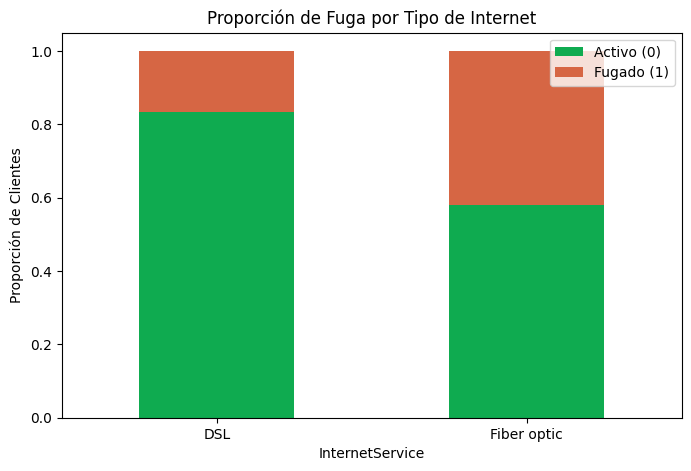

In [183]:
# Grafico de barras cruzado para 'EndDate'
props = pd.crosstab(df_merged_clean['InternetService'], df_merged_clean['EndDate'], normalize='index')

# Graficamos
props.plot(kind='bar', stacked=True, color=["#0fab50", "#d66644"], figsize=(8, 5))
plt.title('Proporción de Fuga por Tipo de Internet')
plt.legend(['Activo (0)', 'Fugado (1)'], loc='upper right')
plt.ylabel('Proporción de Clientes')
plt.xticks(rotation=0)
plt.show()

Analizando la columna 'InternetService', se puede ver una clara tendencia de fuga en el tipo de internet de fibra optica. Ya que cerca del 40 % que usan este servicio tomaron la decision de irse. 

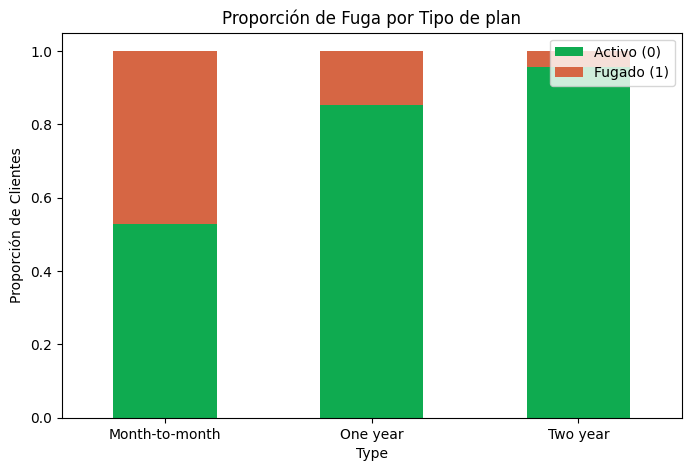

In [184]:
# Grafico de barras cruzado para 'EndDate'
props = pd.crosstab(df_merged_clean['Type'], df_merged_clean['EndDate'], normalize='index')

# Graficamos
props.plot(kind='bar', stacked=True, color=["#0fab50", "#d66644"], figsize=(8, 5))
plt.title('Proporción de Fuga por Tipo de plan')
plt.legend(['Activo (0)', 'Fugado (1)'], loc='upper right')
plt.ylabel('Proporción de Clientes')
plt.xticks(rotation=0)
plt.show()

Analizando esta columna 'Type' donde existen 3 tipos de servicios: Month-to-month, One year type y Two year, se observa una creciente tendencia en la cual, entre mas tiempo es el tipo de servicio, menos personas deciden fugarse. Cerca del 50% de las personas que usan el plan Month-to-Month tienden mas a declinar el plan, mientras que menos del 10% con el plan de mayor tiempo 'Two year' declinan el plan.

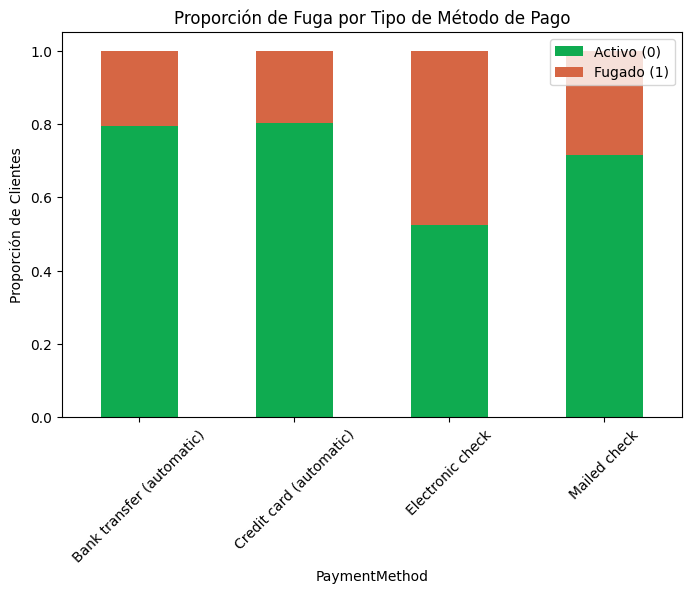

In [185]:
# Grafico de barras cruzado para 'EndDate'
props = pd.crosstab(df_merged_clean['PaymentMethod'], df_merged_clean['EndDate'], normalize='index')

# Graficamos
props.plot(kind='bar', stacked=True, color=["#0fab50", "#d66644"], figsize=(8, 5))
plt.title('Proporción de Fuga por Tipo de Método de Pago')
plt.legend(['Activo (0)', 'Fugado (1)'], loc='upper right')
plt.ylabel('Proporción de Clientes')
plt.xticks(rotation=45)
plt.show()

Con esta columna del metodo de pago, se aprecia que los pagos automaticos generan menos fugas, comparados con los otros 2, que representan 'Electronic Check' y 'Mailed check', siendo 'Electronic check' el metodo que mas fuga genera, cerca del 50%

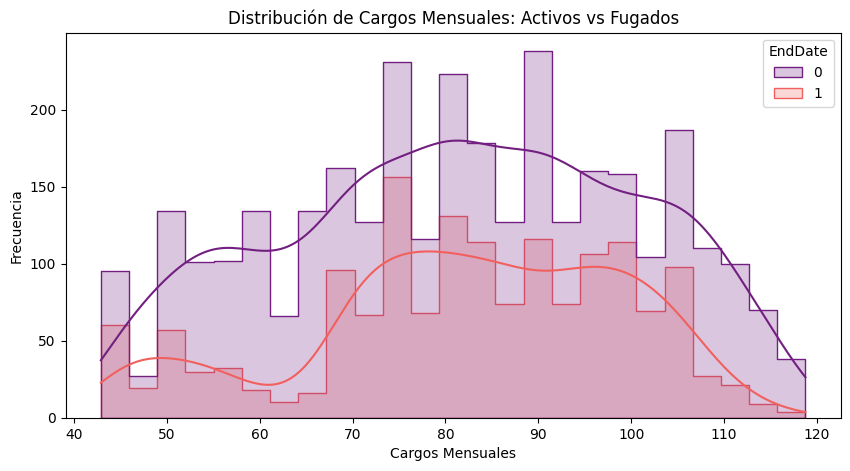

In [186]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_merged_clean, x='MonthlyCharges', hue='EndDate', kde=True, element="step", palette='magma')
plt.title('Distribución de Cargos Mensuales: Activos vs Fugados')
plt.xlabel('Cargos Mensuales')
plt.ylabel('Frecuencia')
plt.show()

Es interesante ver que la campana normal para activos y fugas son similares entre 70 y 110 USD. Esto indica que el precio mensual alto por sí solo no es el único culpable, ya que tienes mucha gente pagando 90 USD que se queda (púrpura) y mucha que se va (rojo). Sin embargo, nota que en los precios bajos (40-60 USD), la proporción de gente que se queda es mucho mayor, por lo que la "zona de peligro" de fuga comienza a partir de los 70 USD mensuales.

C:\Users\alan_\AppData\Local\Temp\ipykernel_23148\3844914179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='EndDate', y='TotalCharges', data=df_merged_clean, palette='Set2')


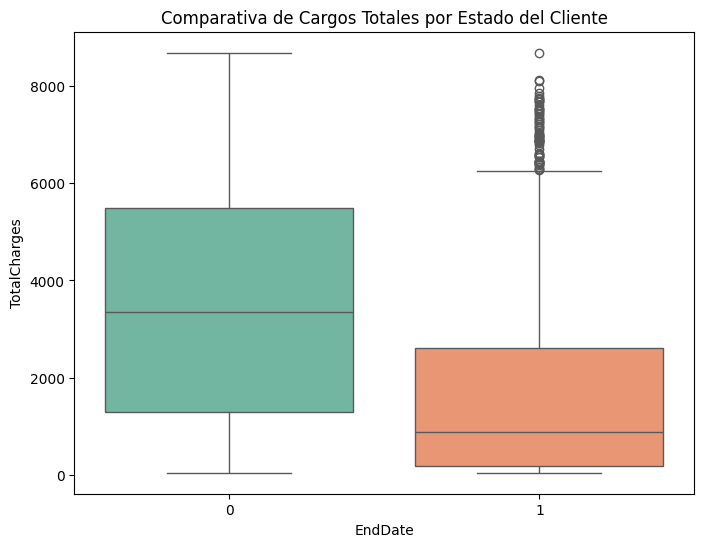

In [187]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='EndDate', y='TotalCharges', data=df_merged_clean, palette='Set2')
plt.title('Comparativa de Cargos Totales por Estado del Cliente')
plt.show()

En la imagen se puede apreciar que la mediana de TotalCharges para los fugados (1) es de 890 USD, mientras que para los que se quedan (0) es de 3,341 USD. Los clientes que cancelan tienen cargos totales mucho más bajos. Esto no significa que paguen menos al mes (de hecho, tu tabla muestra que los fugados pagan en promedio 82.25 USD vs 81.51 USD de los activos). Son personas que contratan planes caros (promedio 82 USD) pero se van muy rápido, por eso su cargo "Total" no alcanza a subir. Hay un problema de "Onboarding" o de expectativa vs. realidad en los primeros meses. Lo cual esto ultimo encaja perfecto con la cantidad mayor de fuga en la columna type

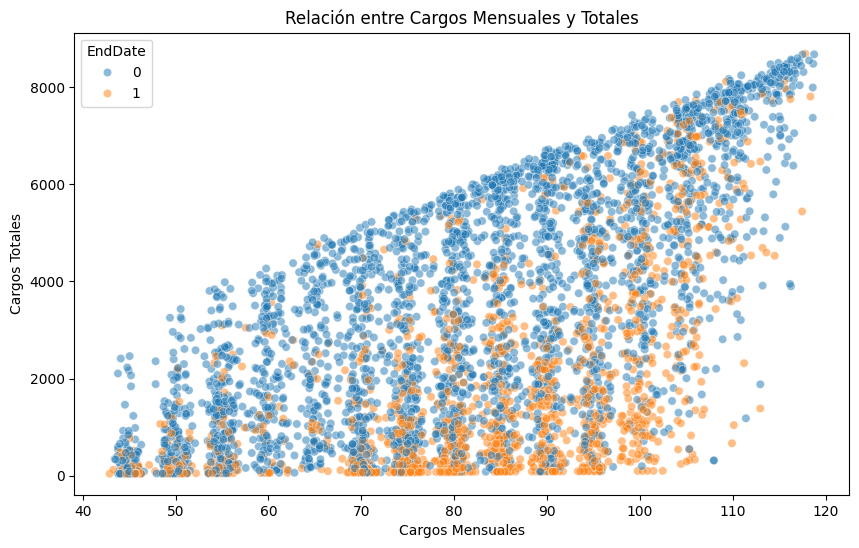

In [188]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged_clean, x='MonthlyCharges', y='TotalCharges', hue='EndDate', alpha=0.5)
plt.title('Relación entre Cargos Mensuales y Totales')
plt.xlabel('Cargos Mensuales')
plt.ylabel('Cargos Totales')
plt.show()

En este grafico hay una "mancha" naranja (fugados) muy densa en la parte inferior derecha del gráfico. Esos puntos naranjas son clientes con cargos mensuales altos (eje X entre 70 y 110) pero con cargos totales bajísimos (eje Y cerca de 0). Esos son los  "fugados tempranos". Clientes que entran pagando mucho y cancelan casi de inmediato.

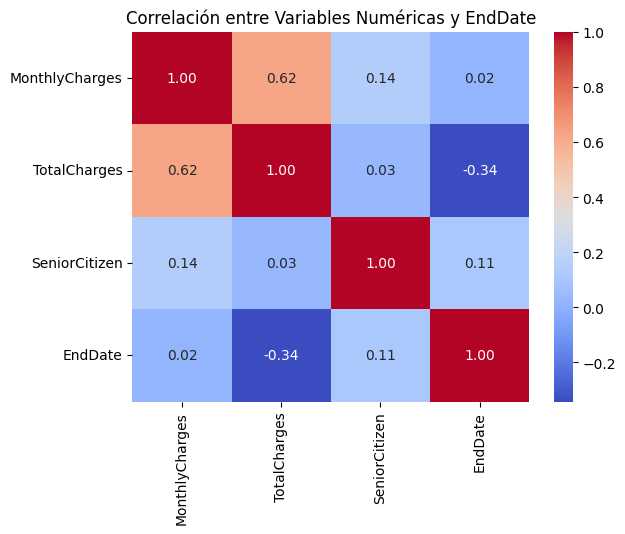

In [189]:
numeric_cols = ['MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'EndDate']
corr_matrix = df_merged_clean[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre Variables Numéricas y EndDate')
plt.show()

En la grafica se ve una correlación negativa de -0.34 entre EndDate (Churn) y TotalCharges.A menor cargo total (menos tiempo en la empresa), mayor probabilidad de fuga. La correlación entre MonthlyCharges y EndDate es casi cero (0.02). Esto rompe el mito de que "se van porque es caro". Se van por otra razón (posiblemente mala calidad del servicio o falta de compromiso a largo plazo), pero el precio mensual les da igual a ambos grupos.

In [190]:
# Comparamos la media y mediana de los cargos para cada grupo
resumen = df_merged_clean.groupby('EndDate')[['MonthlyCharges', 'TotalCharges']].agg(['mean', 'median', 'std'])
print(resumen)

        MonthlyCharges                    TotalCharges                       
                  mean  median        std         mean    median          std
EndDate                                                                      
0             81.51362  81.500  18.883664   3480.67463  3341.275  2403.202644
1             82.25000  84.125  17.047215   1719.08512   890.250  1968.407799


Conclusion: El perfil del cliente que cancela no es el que busca lo más barato, sino el cliente nuevo de alto valor. Se pierden  clientes que aceptan pagar facturas altas (~82 USD) pero que no encuentran valor suficiente para quedarse más de unos pocos meses, lo que genera que su valor de vida (TotalCharges) sea muy bajo comparado con los clientes leales.

# Codificacion y creación del modelo

In [194]:
# Resetear index para preparar el dataframe para modelado
df_merged_clean = df_merged_clean.reset_index()

print(df_merged_clean.info())
df_merged_clean.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4835 entries, 0 to 4834
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   level_0           4835 non-null   int64         
 1   index             4835 non-null   int64         
 2   customerID        4835 non-null   object        
 3   gender            4835 non-null   object        
 4   SeniorCitizen     4835 non-null   int64         
 5   Partner           4835 non-null   object        
 6   Dependents        4835 non-null   object        
 7   InternetService   4835 non-null   object        
 8   OnlineSecurity    4835 non-null   object        
 9   OnlineBackup      4835 non-null   object        
 10  DeviceProtection  4835 non-null   object        
 11  TechSupport       4835 non-null   object        
 12  StreamingTV       4835 non-null   object        
 13  StreamingMovies   4835 non-null   object        
 14  BeginDate         4835 n

,level_0,index,customerID,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,BeginDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines,EndDate
0,0,0,0002-ORFBO,Female,0,Yes,Yes,DSL,No,Yes,...,Yes,No,2019-05-01,One year,Yes,Mailed check,65.6,593.30,No,0
1,1,1,0003-MKNFE,Male,0,No,No,DSL,No,No,...,No,Yes,2019-05-01,Month-to-month,No,Mailed check,59.9,542.40,Yes,0
2,2,2,0004-TLHLJ,Male,0,No,No,Fiber optic,No,No,...,No,No,2019-09-01,Month-to-month,Yes,Electronic check,73.9,280.85,No,1
3,3,3,0011-IGKFF,Male,1,Yes,No,Fiber optic,No,Yes,...,Yes,Yes,2018-12-01,Month-to-month,Yes,Electronic check,98.0,1237.85,No,1
4,4,4,0013-EXCHZ,Female,1,Yes,No,Fiber optic,No,No,...,Yes,No,2019-09-01,Month-to-month,Yes,Mailed check,83.9,267.40,No,1


In [195]:
# Borrar columnas level_0 e index
df_merged_clean = df_merged_clean.drop(['level_0', 'index'], axis=1)

In [196]:
print(df_merged_clean.info())
df_merged_clean.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4835 entries, 0 to 4834
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customerID        4835 non-null   object        
 1   gender            4835 non-null   object        
 2   SeniorCitizen     4835 non-null   int64         
 3   Partner           4835 non-null   object        
 4   Dependents        4835 non-null   object        
 5   InternetService   4835 non-null   object        
 6   OnlineSecurity    4835 non-null   object        
 7   OnlineBackup      4835 non-null   object        
 8   DeviceProtection  4835 non-null   object        
 9   TechSupport       4835 non-null   object        
 10  StreamingTV       4835 non-null   object        
 11  StreamingMovies   4835 non-null   object        
 12  BeginDate         4835 non-null   datetime64[ns]
 13  Type              4835 non-null   object        
 14  PaperlessBilling  4835 n

,customerID,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,BeginDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines,EndDate
0,0002-ORFBO,Female,0,Yes,Yes,DSL,No,Yes,No,Yes,Yes,No,2019-05-01,One year,Yes,Mailed check,65.6,593.30,No,0
1,0003-MKNFE,Male,0,No,No,DSL,No,No,No,No,No,Yes,2019-05-01,Month-to-month,No,Mailed check,59.9,542.40,Yes,0
2,0004-TLHLJ,Male,0,No,No,Fiber optic,No,No,Yes,No,No,No,2019-09-01,Month-to-month,Yes,Electronic check,73.9,280.85,No,1
3,0011-IGKFF,Male,1,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,2018-12-01,Month-to-month,Yes,Electronic check,98.0,1237.85,No,1
4,0013-EXCHZ,Female,1,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,2019-09-01,Month-to-month,Yes,Mailed check,83.9,267.40,No,1


In [ ]:
# Codificar las columnas del dataframe para modelado
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df_merged_clean.columns:
    if df_merged_clean[col].dtype == 'object' and col not in ['customerID', 'InternetService', 'Type', 'PaymentMethod']:
        df_merged_clean[col] = le.fit_transform(df_merged_clean[col])